# Guided Inference: Qualitative Hints for Quantitative Predictions

This notebook evaluates Gemini 3.1 Flash lite's predictive performance when provided with qualitative "hints" about the semantic content of video titles. These hints are derived from the 15-dimensional PCA space and OLS model significance found in the `numeric-inference` notebook.

## Methodology:
1. **Contextual Prompting**: For each channel, the LLM is provided with global success drivers, definitions of significant semantic dimensions, and statistical benchmarks.
2. **Qualitative Hints**: For each video in a test batch (10 videos), the LLM receives labels indicating how the title scores on the 5 most significant dimensions for that channel. Labels are assigned based on the training distribution (e.g., "significantly negative" for top 5% values).
3. **Zero-Shot Prediction**: The LLM predicts logarithmic views for each title.
4. **Comparative Evaluation**: Accuracy is measured against actual views and OLS numeric benchmarks using MAE and R2 metrics.

## 1. Setup and Dependencies

In [2]:
# Install google-generativeai. We avoid upgrading standard libraries like numpy/pandas
# to prevent version conflicts (e.g. NumPy 2.0 AttributeError) in the Colab environment.
!pip install -q -U google-generativeai

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, userdata
import google.generativeai as genai
from datetime import datetime
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats

# Mount Google Drive
drive.mount('/content/drive')

# Configure Gemini
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)
MODEL_NAME = 'gemini-3.1-flash-lite'

# Constants
BASE_PATH = '/content/drive/MyDrive/numeric_inference_outputs/'
EVAL_DATA_FILE = os.path.join(BASE_PATH, 'top_significant_channels_eval.json')
LLM_ANALYSIS_FILE = os.path.join(BASE_PATH, 'llm_analysis_results.json')
OUTPUT_FILE = os.path.join(BASE_PATH, 'guided_inference_results.json')
CACHE_FILE = os.path.join(BASE_PATH, 'guided_inference_cache.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Data and Define Label Distribution

We map embedding values to qualitative labels based on the following training distribution:
- significantly negative: bottom 5%
- negative: next 10%
- mildly negative: next 20%
- neutral: middle 30%
- mildly positive: next 20%
- positive: next 10%
- significative positive: top 5%

In [3]:
with open(EVAL_DATA_FILE, 'r') as f:
    eval_dataset = json.load(f)

with open(LLM_ANALYSIS_FILE, 'r') as f:
    llm_analysis = json.load(f)

LABEL_ORDER = [
    "significantly negative", "negative", "mildly negative",
    "neutral",
    "mildly positive", "positive", "significative positive"
]

DISTRIBUTION = [0.05, 0.10, 0.20, 0.30, 0.20, 0.10, 0.05]
CUMULATIVE_DIST = np.cumsum(DISTRIBUTION)

def get_channel_stats(train_videos):
    log_views = np.log1p([v['actual_views'] for v in train_videos])
    return {
        'min': float(np.min(log_views)),
        'max': float(np.max(log_views)),
        'mean': float(np.mean(log_views)),
        'q1': float(np.percentile(log_views, 25)),
        'median': float(np.median(log_views)),
        'q3': float(np.percentile(log_views, 75))
    }

def get_dimension_thresholds(channel_data):
    train_vids = channel_data['train_videos']
    p_values = np.array(channel_data['model']['p_values'][1:])
    sig_indices = np.argsort(p_values)[:5]

    thresholds = {}
    for idx in sig_indices:
        # Use raw embedding values for thresholds
        vals = [v['reduced_embedding'][idx] for v in train_vids]
        t_vals = [np.percentile(vals, p * 100) for p in CUMULATIVE_DIST[:-1]]
        thresholds[int(idx)] = t_vals

    return thresholds, sig_indices

def get_label(val, thresholds):
    for idx, t in enumerate(thresholds):
        if val <= t:
            return LABEL_ORDER[idx]
    return LABEL_ORDER[-1]

channel_info = {}
for c in eval_dataset:
    cid = c['channel_id']
    stats_dict = get_channel_stats(c['train_videos'])
    thresh, sig_idx = get_dimension_thresholds(c)
    channel_info[cid] = {
        'stats': stats_dict,
        'thresholds': thresh,
        'sig_indices': sig_idx
    }

print(f"Processed {len(eval_dataset)} channels.")

Processed 10 channels.


## 3. Utility Functions

In [4]:
def load_cache():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=4)

def get_gemini_completion(prompt, cache, key, retries=3, sleep_time=2):
    if key in cache:
        return cache[key]

    model = genai.GenerativeModel(MODEL_NAME)

    for i in range(retries):
        try:
            response = model.generate_content(prompt)
            text = response.text
            cache[key] = text
            save_cache(cache)
            time.sleep(sleep_time)
            return text
        except Exception as e:
            print(f"Error on attempt {i+1}: {e}")
            if i < retries - 1:
                time.sleep(sleep_time * (i + 1))
            else:
                raise e
    return None

def parse_json_response(text):
    import re
    try:
        # Strip markdown
        text = re.sub(r'```json\s*', '', text)
        text = re.sub(r'```\s*', '', text)
        # Find JSON object or list
        match = re.search(r'(\{.*\}|\[.*\])', text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    return None

## 4. Guided Inference Engine

We predict views in batches of 10. For each title, we provide qualitative hints (labels) for the 5 most significant dimensions.

In [5]:
cache = load_cache()
all_results = []

for channel in eval_dataset:
    cid = channel['channel_id']
    cname = channel['channel_name']
    info = channel_info[cid]
    stats_vals = info['stats']
    sig_indices = info['sig_indices']
    thresholds = info['thresholds']

    global_desc = llm_analysis['global_performance_descriptions'].get(cid, "")
    dim_analysis = llm_analysis['channel_significant_dimension_analysis'].get(cid, "")
    dim_definitions = [llm_analysis['dimension_definitions'][idx] for idx in sig_indices]

    test_vids = channel['test_videos']
    channel_results = []

    print(f"\n>>> Processing Channel: {cname}")

    for i in range(0, len(test_vids), 10):
        batch = test_vids[i:i+10]
        batch_titles_lower = [v['title'].lower() for v in batch]

        video_list_str = ""
        for v in batch:
            hints = []
            for idx in sig_indices:
                label = get_label(v['reduced_embedding'][idx], thresholds[idx])
                hints.append(f"Dim {idx}: {label}")
            video_list_str += f"- Title: {v['title']}\n  Hints: {', '.join(hints)}\n"

        dim_info_str = "\n".join([f"Dimension {idx}: {desc}" for idx, desc in zip(sig_indices, dim_definitions)])

        prompt = f"""You are a YouTube performance analyst.

Channel: {cname}

Global Success Drivers:
{global_desc}

Significant Dimension Definitions:
{dim_info_str}

Significant Dimension Analysis for this channel:
{dim_analysis}

Training Data Metrics (Logarithmic Views):
- Max: {stats_vals['max']:.2f}
- Min: {stats_vals['min']:.2f}
- Average: {stats_vals['mean']:.2f}
- Q1 (25th): {stats_vals['q1']:.2f}
- Median (50th): {stats_vals['median']:.2f}
- Q3 (75th): {stats_vals['q3']:.2f}

Task: Predict the logarithmic views for the following videos.
You are provided with qualitative hints for each title indicating its score on the most significant semantic dimensions.

Labels for dimension scores follow this distribution in the training data:
- significantly negative (5%)
- negative (10%)
- mildly negative (20%)
- neutral (30%)
- mildly positive (20%)
- positive (10%)
- significative positive (5%)

IMPORTANT: A negative value (e.g., "significantly negative") in a given dimension may produce a positive impact on views depending on the channel's specific dynamics. This is why we provide both the dimension score and the analysis of how that dimension relates to views. Please use this information to minimize confusion and improve prediction accuracy.

Return the results as a JSON object where keys are the video titles and values are the predicted logarithmic views (floats).

Example:
{{"Video Title 1": 10.5, "Video Title 2": 11.2}}

Videos to predict:
{video_list_str}
"""

        if i == 0:
            print("\n--- First Batch Prompt ---")
            print(prompt)
            print("--------------------------\n")

        res_text = get_gemini_completion(prompt, cache, f"guided_inf_{cid}_batch_{i//10}")
        batch_data = parse_json_response(res_text)

        valid_in_batch = 0
        if batch_data and isinstance(batch_data, dict):
            # Normalize keys to lower case for matching
            normalized_batch_data = {str(k).lower(): v for k, v in batch_data.items()}

            for idx_in_batch, v_orig in enumerate(batch):
                t_lower = v_orig['title'].lower()
                if t_lower in normalized_batch_data:
                    pred_val = normalized_batch_data[t_lower]
                    try:
                        res_obj = {
                            'title': v_orig['title'],
                            'predicted_log_views': float(pred_val),
                            'actual_log_views': np.log1p(v_orig['actual_views']),
                            'numeric_prediction': np.log1p(v_orig['predicted_views']),
                            'video_id': v_orig['video_id'],
                            'channel_id': cid,
                            'channel_name': cname
                        }
                        channel_results.append(res_obj)
                        valid_in_batch += 1
                    except (ValueError, TypeError):
                        pass

        print(f"Batch {i//10 + 1}: {valid_in_batch}/{len(batch)} valid predictions.")

    all_results.extend(channel_results)

print(f"\nCompleted. Total valid predictions: {len(all_results)}")


>>> Processing Channel: The Prof G Pod – Scott Galloway

--- First Batch Prompt ---
You are a YouTube performance analyst.

Channel: The Prof G Pod – Scott Galloway

Global Success Drivers:
The performance discrepancy on *The Prof G Pod* channel is driven by a clear divide between **macro-existential anxiety** and **niche technical analysis.**

### Why Top Videos Perform Well
1.  **The "High-Stakes" Narrative:** Top-performing videos focus on heavy, structural themes: the decline of democracy, geopolitical warfare, economic collapse, and the existential status of America. Titles like "The Collapse of American Trust" or "The End of American Power" leverage fear and curiosity.
2.  **The Authority Signal:** The titles prominently feature recognizable "name-brand" experts (Fareed Zakaria, Sam Harris, Ian Bremmer, Fiona Hill). The framing suggests an intellectual high-ground debate rather than a mere market update.
3.  **Broad Scope:** These topics appeal to the "generalist intellectual." 

## 5. Evaluation and Analysis

We compare the accuracy of Gemini's guided predictions against the actual log-views and the OLS numeric baseline.

In [6]:
df = pd.DataFrame(all_results)

def calculate_metrics(group):
    actual = group['actual_log_views']
    llm_pred = group['predicted_log_views']
    num_pred = group['numeric_prediction']

    return pd.Series({
        'LLM MAE': mean_absolute_error(actual, llm_pred),
        'Numeric MAE': mean_absolute_error(actual, num_pred),
        'LLM R2': r2_score(actual, llm_pred),
        'Numeric R2': r2_score(actual, num_pred),
        'Count': len(group)
    })

channel_summary = df.groupby('channel_name').apply(calculate_metrics).sort_values('LLM MAE')
display(channel_summary)

global_llm_mae = mean_absolute_error(df['actual_log_views'], df['predicted_log_views'])
global_num_mae = mean_absolute_error(df['actual_log_views'], df['numeric_prediction'])
global_llm_r2 = r2_score(df['actual_log_views'], df['predicted_log_views'])
global_num_r2 = r2_score(df['actual_log_views'], df['numeric_prediction'])

print(f"\n--- Global Metrics ---")
print(f"LLM Global MAE: {global_llm_mae:.3f} | Numeric Global MAE: {global_num_mae:.3f}")
print(f"LLM Global R2:  {global_llm_r2:.3f} | Numeric Global R2:  {global_num_r2:.3f}")

/tmp/ipykernel_2668/1764743293.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  channel_summary = df.groupby('channel_name').apply(calculate_metrics).sort_values('LLM MAE')


,LLM MAE,Numeric MAE,LLM R2,Numeric R2,Count
channel_name,,,,,
Anthony Pompliano,0.615390,0.564431,0.377082,0.418986,131.0
Asianometry,0.633756,0.659460,0.129631,0.029724,58.0
This Week in Startups,0.850912,0.696594,-0.465708,-0.089764,122.0
ARK Invest,0.863915,0.804931,-0.055551,0.116856,61.0
The Prof G Pod – Scott Galloway,0.865293,0.797076,0.100068,0.263881,62.0
a16z,0.960713,1.023711,0.088565,0.103847,72.0
Greg Isenberg,0.965548,0.978196,0.502687,0.499591,59.0
Peter H. Diamandis,1.059634,1.178492,0.349298,0.235828,97.0
Bloomberg Originals,1.218395,1.170185,0.166828,0.263689,132.0



--- Global Metrics ---
LLM Global MAE: 0.959 | Numeric Global MAE: 0.920
LLM Global R2:  0.648 | Numeric Global R2:  0.683


### Visualizing Prediction Accuracy

<Figure size 1200x600 with 0 Axes>

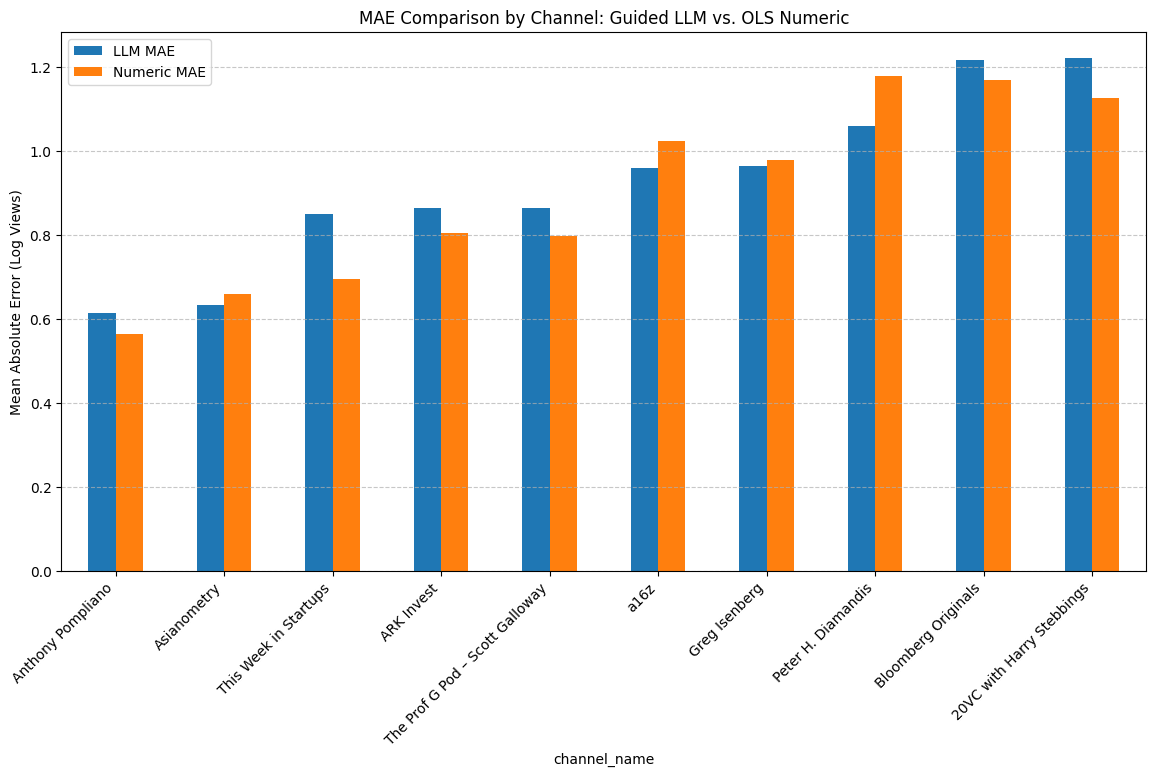

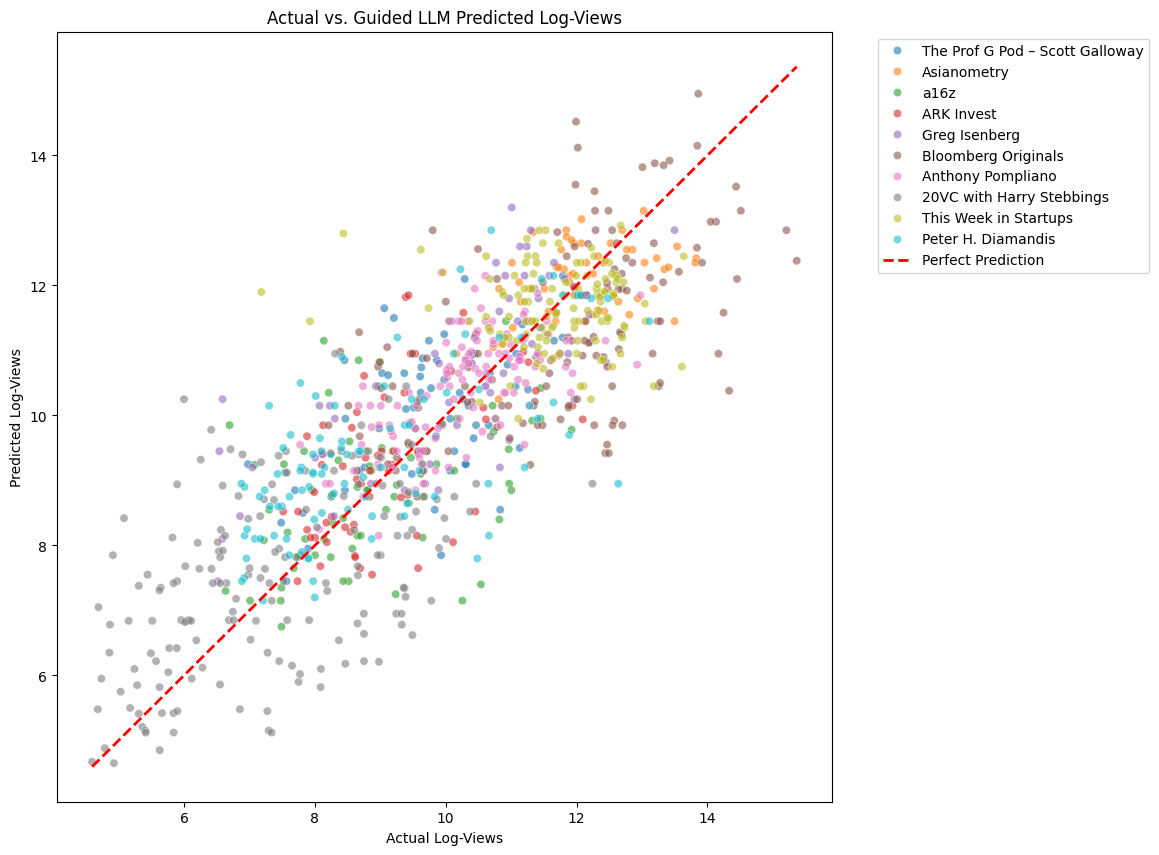

In [7]:
plt.figure(figsize=(12, 6))
channel_summary[['LLM MAE', 'Numeric MAE']].plot(kind='bar', figsize=(14, 7))
plt.title("MAE Comparison by Channel: Guided LLM vs. OLS Numeric")
plt.ylabel("Mean Absolute Error (Log Views)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='actual_log_views', y='predicted_log_views', hue='channel_name', alpha=0.6)
plt.plot([df['actual_log_views'].min(), df['actual_log_views'].max()],
         [df['actual_log_views'].min(), df['actual_log_views'].max()],
         'r--', lw=2, label='Perfect Prediction')
plt.title("Actual vs. Guided LLM Predicted Log-Views")
plt.xlabel("Actual Log-Views")
plt.ylabel("Predicted Log-Views")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 6. Export Results

In [8]:
df.to_json(OUTPUT_FILE, orient='records', indent=4)
print(f"Results exported to {OUTPUT_FILE}")

Results exported to /content/drive/MyDrive/numeric_inference_outputs/guided_inference_results.json
